In [1]:
import os

import openmc
import openmc.model
import openmc.deplete


import numpy as np
import matplotlib.pyplot as plt
import tempfile

In [15]:
gad_result = openmc.deplete.Results('gad_sim/gad_depletion_results.h5')

for step in range(len(gad_result)):
    print(f'Timestep {step}')
    materials = gad_result.export_to_materials(step)
    for mat in materials:
        print(mat.id, mat.name)



Timestep 0
1 coolant
2 fuel
3 clad
4 gap
Timestep 1
1 coolant
2 fuel
3 clad
4 gap
Timestep 2
1 coolant
2 fuel
3 clad
4 gap
Timestep 3
1 coolant
2 fuel
3 clad
4 gap
Timestep 4
1 coolant
2 fuel
3 clad
4 gap
Timestep 5
1 coolant
2 fuel
3 clad
4 gap
Timestep 6
1 coolant
2 fuel
3 clad
4 gap


/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)


In [16]:
for i, result in enumerate(gad_result):
    print(result.index_mat)
    break

{'27': np.int64(0), '30': np.int64(1)}


In [19]:
id = '27'
print(type(id))

time, concentration = gad_result.get_atoms(mat=id, nuc='U235', time_units='d')
print(f'Time (days): {time}')
print(f'U235 concentration (atoms/b-cm): {concentration}')

<class 'str'>
Time (days): [ 0.    0.25  1.25  6.25 16.25 36.25 66.25]
U235 concentration (atoms/b-cm): [1.26684105e+25 1.26539321e+25 1.25960602e+25 1.23078633e+25
 1.17411158e+25 1.06495913e+25 9.11160111e+24]


In [10]:
def plot_nuclides(results, material_id, nuclides, title ):
    
    for nuc in nuclides:
        time, concentration = results.get_atoms(mat=material_id, nuc=nuc, nuc_units='atom/cm3', time_units='d')
        plt.plot(time, concentration, label=nuc)

    plt.xlabel('Time [days]')
    plt.ylabel('concentration [atom/cm³]')
    plt.title(title)
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    plt.show()

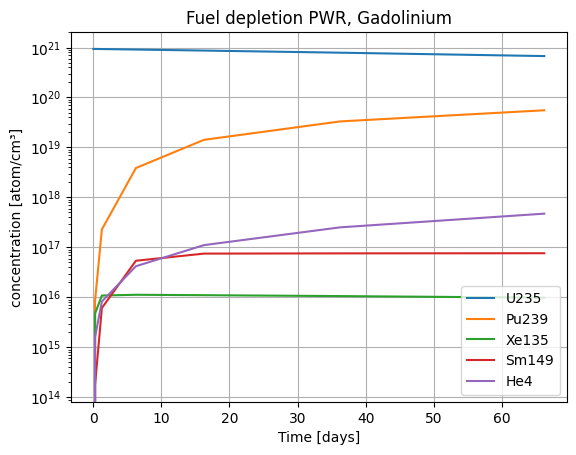

In [ ]:
nuclides_to_plot = ['U235', 'Pu239', 'Xe135', 'Sm149', 'He4']
fuel_id = '27'
plot_nuclides(gad_result, fuel_id, nuclides_to_plot)


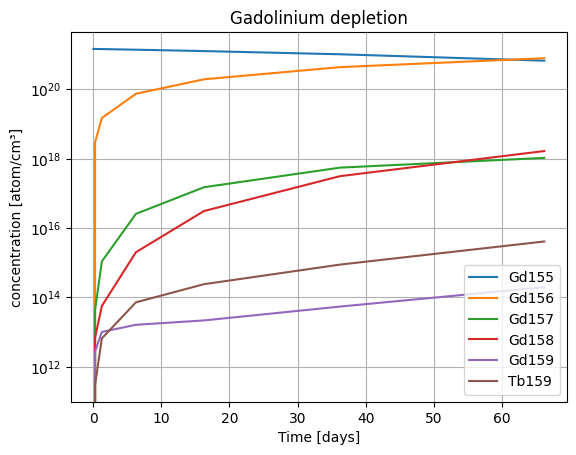

In [16]:
nuclides_to_plot = ['Gd155', 'Gd156', 'Gd157', 'Gd158', 'Gd159', 'Tb159']
fuel_id = '30'
plot_nuclides(gad_result, fuel_id, nuclides_to_plot, 'Gadolinium depletion')

In [ ]:
boron_result = openmc.deplete.Results('boron_sim/boron_depletion_results.h5')

for step in range(len(boron_result)):
    print(f'Timestep {step}')
    materials = boron_result.export_to_materials(step)
    for mat in materials:
        print(mat.id, mat.name)

Timestep 0
1 coolant
2 fuel
3 clad
4 gap
Timestep 1
1 coolant
2 fuel
3 clad
4 gap
Timestep 2
1 coolant
2 fuel
3 clad
4 gap
Timestep 3
1 coolant
2 fuel
3 clad
4 gap
Timestep 4
1 coolant
2 fuel
3 clad
4 gap
Timestep 5
1 coolant
2 fuel
3 clad
4 gap
Timestep 6
1 coolant
2 fuel
3 clad
4 gap


/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)


In [ ]:
for i, result in enumerate(boron_result):
    print(result.index_mat)
    break

{'1': np.int64(0), '2': np.int64(1)}


In [ ]:
id = '1'
print(type(id))

time, concentration = boron_result.get_atoms(mat=id, nuc='U235', time_units='d')
print(f'Time (days): {time}')
print(f'U235 concentration (atoms/b-cm): {concentration}')

<class 'str'>
Time (days): [ 0.    0.25  1.25  6.25 16.25 36.25 66.25]
U235 concentration (atoms/b-cm): [ 0.00000000e+00 -4.92004113e-04 -7.48672124e-01 -3.94677220e+02
 -1.03442707e+04 -1.29068901e+05 -7.68867798e+05]


In [ ]:
materials = boron_result.export_to_materials(-1)
materials

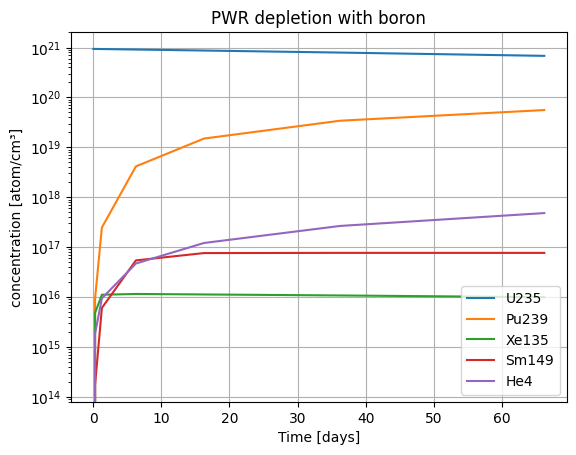

In [11]:
nuclides_to_plot = ['U235', 'Pu239', 'Xe135', 'Sm149', 'He4']
fuel_id = '2'
plot_nuclides(boron_result, fuel_id, nuclides_to_plot, 'PWR depletion with boron')


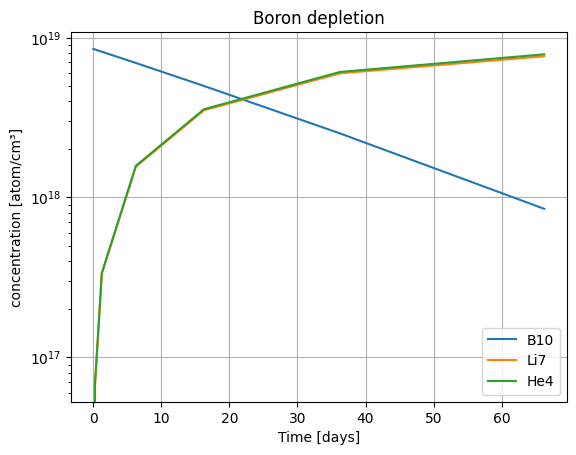

In [ ]:
nuclides_to_plot = ['B10', 'Li7', 'He4']
fuel_id = '1'
plot_nuclides(boron_result, fuel_id, nuclides_to_plot, 'Boron depletion')

In [21]:
shutdown_result = openmc.deplete.Results('shutdown_sim/shutdown_results.h5')

for i, result in enumerate(shutdown_result):
    print(result.index_mat)
    break

{'2': np.int64(0)}


Time (days): [ 0.   0.1  0.2  0.7  1.7  3.7  7.7 15.7 27.7]
Xe135 concentration (atoms/b-cm): [1.56324690e+20 3.86853450e+20 5.20955272e+20 5.33945311e+20
 1.49082246e+20 5.11453875e+18 3.77100758e+15 1.79719146e+09
 5.87747997e-01]


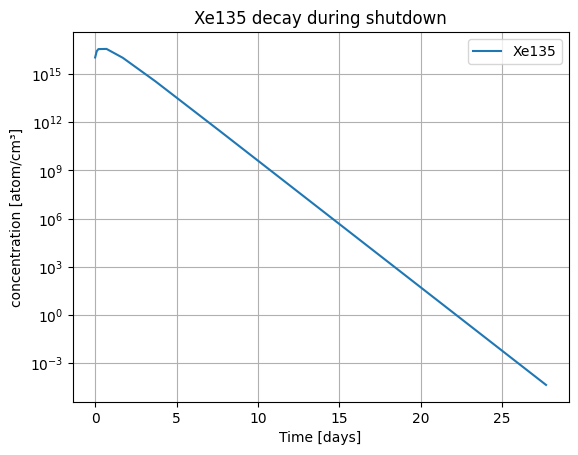

In [23]:
id = '2'
nuclide = ['Xe135']
time, concentration = shutdown_result.get_atoms(mat=id, nuc=nuclide[0], time_units='d')
print(f'Time (days): {time}')
print(f'Xe135 concentration (atoms/b-cm): {concentration}')

plot_nuclides(shutdown_result, id, nuclide, 'Xe135 decay during shutdown')
